In [ ]:
from pathlib import Path
import pandas as pd

# === ここだけ変更すればOK ===
# target_skills = [58, 74, 277, 279, 280]
# target_skills = [47, 49, 50, 58, 67, 74, 277, 278, 279, 280]
target_skills = [47, 49, 50, 58, 67, 70, 74, 77, 79, 86, 277, 278, 279, 280, 309]
# ===========================

base_dir = Path("../../data/processed/assistments_2009_2010/first_all_dina_estimation")
skill_str = "_".join([f"s{s}" for s in sorted(set(target_skills))])
data_dir = base_dir / skill_str

alpha_current_path = data_dir / "alpha_current.csv"
alpha_future_path  = data_dir / "alpha_future.csv"

print("data_dir:", data_dir)
print("exists alpha_current:", alpha_current_path.exists())
print("exists alpha_future :", alpha_future_path.exists())

df_cur = pd.read_csv(alpha_current_path)
df_fut = pd.read_csv(alpha_future_path)

# 列の整合チェック
skill_cols = [f"skill_{s}" for s in sorted(set(target_skills))]
missing_cur = [c for c in skill_cols if c not in df_cur.columns]
missing_fut = [c for c in skill_cols if c not in df_fut.columns]
if missing_cur or missing_fut:
    raise ValueError(f"Missing columns. current={missing_cur}, future={missing_fut}")

# user_id の整合（順序がズレていても揃える）
df = df_cur[["user_id"] + skill_cols].merge(
    df_fut[["user_id"] + skill_cols],
    on="user_id",
    suffixes=("_cur", "_fut"),
    how="inner",
)

print("n_users:", len(df))
df.head()


data_dir: ../../data/processed/assistments_2009_2010/first_all_dina_estimation/s47_s49_s50_s58_s67_s74_s277_s278_s279_s280
exists alpha_current: True
exists alpha_future : True
n_users: 77


,user_id,skill_47_cur,skill_49_cur,skill_50_cur,skill_58_cur,skill_67_cur,skill_74_cur,skill_277_cur,skill_278_cur,skill_279_cur,...,skill_47_fut,skill_49_fut,skill_50_fut,skill_58_fut,skill_67_fut,skill_74_fut,skill_277_fut,skill_278_fut,skill_279_fut,skill_280_fut
0,53167,1,1,1,0,1,0,1,0,1,...,1,1,1,0,1,0,1,0,1,0
1,70688,1,1,0,0,1,0,1,0,1,...,1,1,1,0,1,0,1,0,1,0
2,70695,1,1,1,0,1,0,1,0,1,...,1,1,0,0,1,0,1,0,1,0
3,70702,1,1,1,0,1,0,1,0,1,...,1,1,1,0,1,0,1,0,1,0
4,70704,1,1,1,0,1,0,1,0,1,...,1,1,1,0,1,0,1,0,1,0


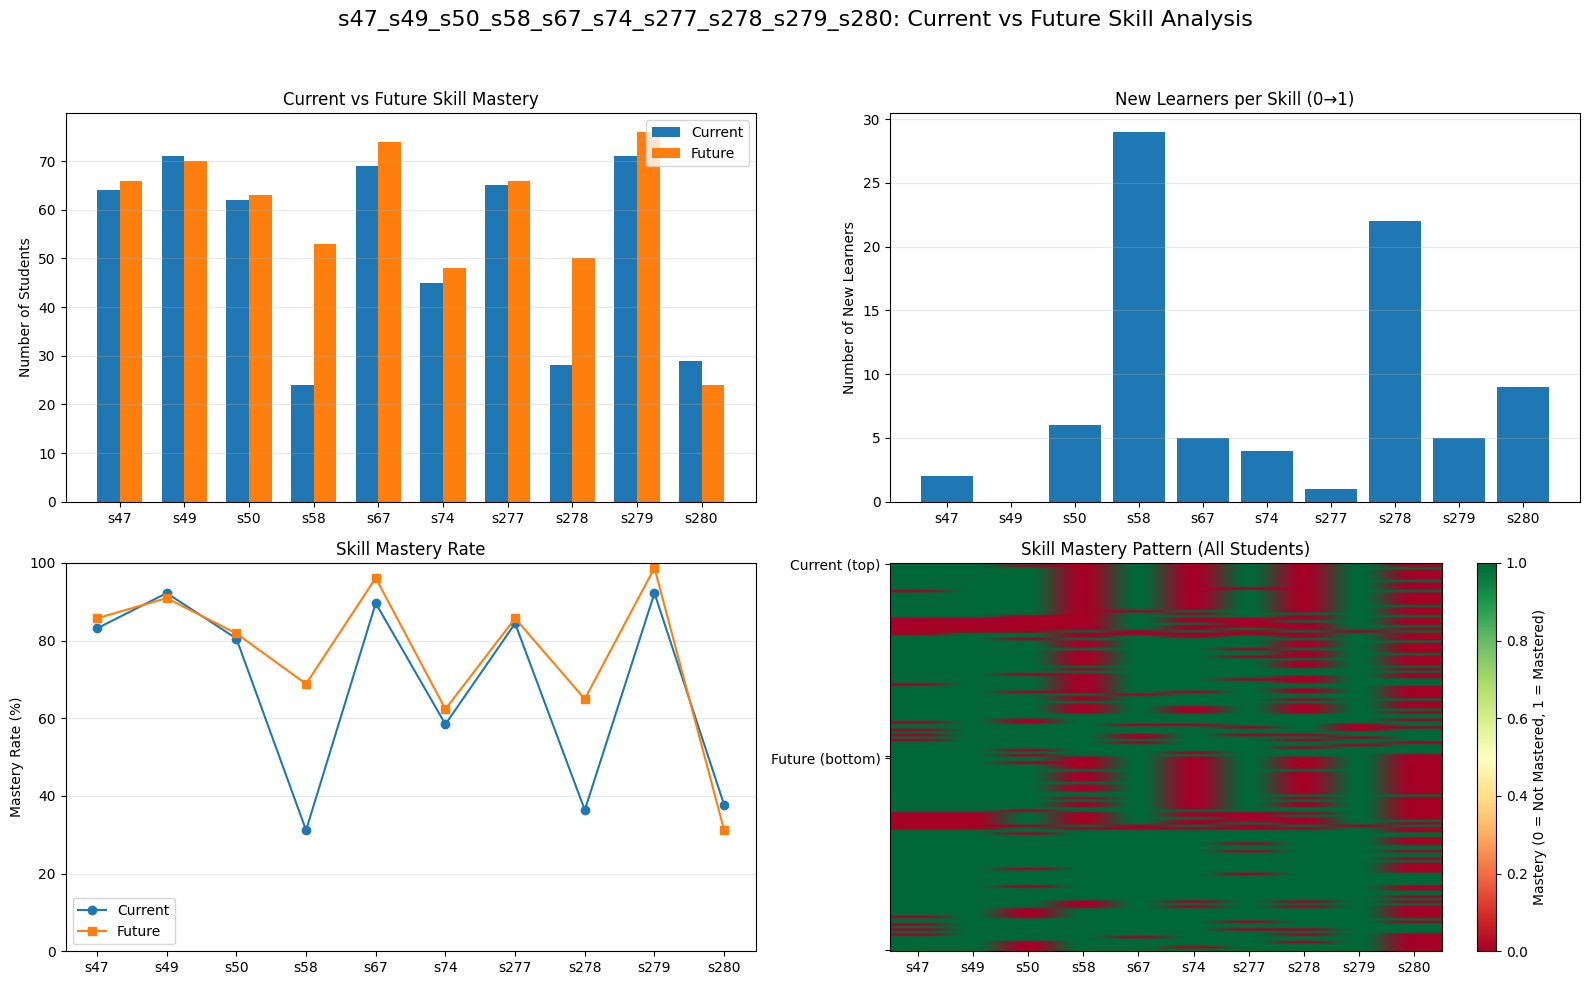

In [2]:
import numpy as np
import matplotlib.pyplot as plt

skills = sorted(set(target_skills))
skill_labels = [f"s{s}" for s in skills]
x = np.arange(len(skills))
n_users = len(df)

# ===== 集計 =====
cur_counts = np.array([df[f"skill_{s}_cur"].sum() for s in skills])
fut_counts = np.array([df[f"skill_{s}_fut"].sum() for s in skills])

new_learners = np.array([
    ((df[f"skill_{s}_cur"] == 0) & (df[f"skill_{s}_fut"] == 1)).sum()
    for s in skills
])

cur_rate = cur_counts / n_users * 100
fut_rate = fut_counts / n_users * 100

# ヒートマップ用（上: current, 下: future）
heatmap_data = np.vstack([
    df[[f"skill_{s}_cur" for s in skills]].values,
    df[[f"skill_{s}_fut" for s in skills]].values
])

# ===== 図作成 =====
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    f"{'_'.join(skill_labels)}: Current vs Future Skill Analysis",
    fontsize=16
)

# ---- (1) 習得人数（Current vs Future）----
width = 0.35
axes[0, 0].bar(x - width/2, cur_counts, width, label="Current")
axes[0, 0].bar(x + width/2, fut_counts, width, label="Future")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(skill_labels)
axes[0, 0].set_ylabel("Number of Students")
axes[0, 0].set_title("Current vs Future Skill Mastery")
axes[0, 0].legend()
axes[0, 0].grid(axis="y", alpha=0.3)

# ---- (2) 新規習得者数（0→1）----
axes[0, 1].bar(x, new_learners)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(skill_labels)
axes[0, 1].set_ylabel("Number of New Learners")
axes[0, 1].set_title("New Learners per Skill (0→1)")
axes[0, 1].grid(axis="y", alpha=0.3)

# ---- (3) 習得率（％）----
axes[1, 0].plot(x, cur_rate, marker="o", label="Current")
axes[1, 0].plot(x, fut_rate, marker="s", label="Future")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(skill_labels)
axes[1, 0].set_ylabel("Mastery Rate (%)")
axes[1, 0].set_ylim(0, 100)
axes[1, 0].set_title("Skill Mastery Rate")
axes[1, 0].legend()
axes[1, 0].grid(axis="y", alpha=0.3)

# ---- (4) スキル状態ヒートマップ（サンプル表示）----
im = axes[1, 1].imshow(
    heatmap_data,
    aspect="auto",
    cmap="RdYlGn",
    vmin=0,
    vmax=1
)
axes[1, 1].set_xticks(np.arange(len(skills)))
axes[1, 1].set_xticklabels(skill_labels)
axes[1, 1].set_yticks([0, n_users - 1, n_users, 2*n_users - 1])
axes[1, 1].set_yticklabels(["Current (top)", "", "Future (bottom)", ""])
axes[1, 1].set_title("Skill Mastery Pattern (All Students)")

cbar = fig.colorbar(im, ax=axes[1, 1])
cbar.set_label("Mastery (0 = Not Mastered, 1 = Mastered)")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


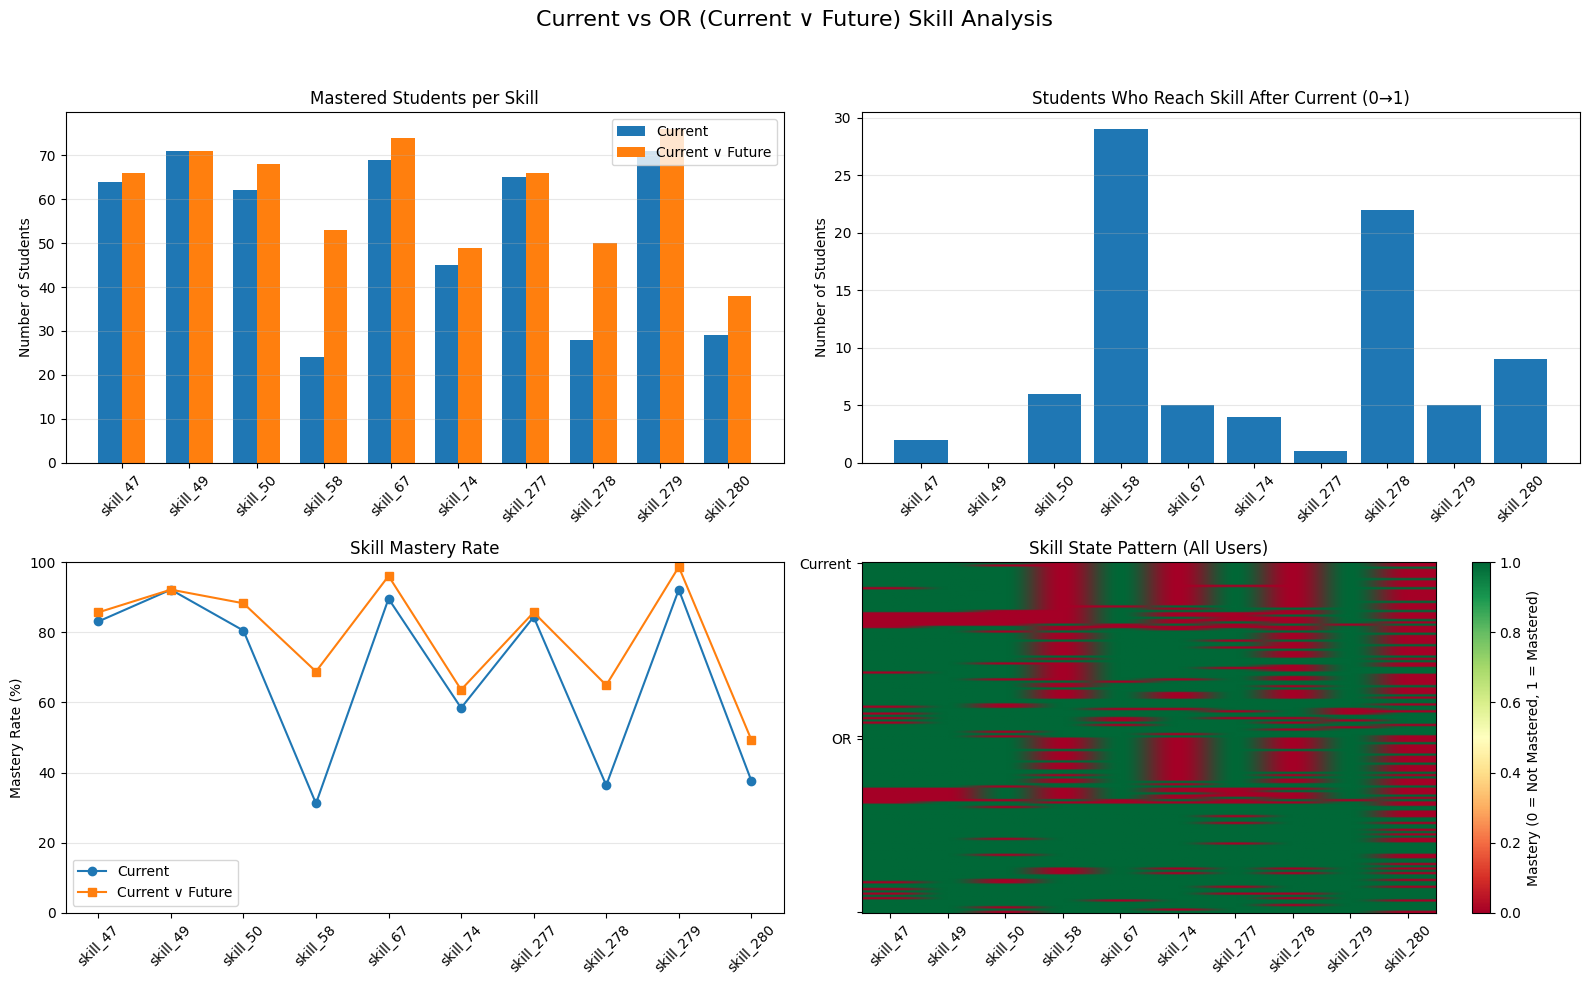

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== 前提 =====
# df_cur, df_fut がすでに存在
# 各列: skill_xxx (0/1), 行: user

skill_cols = [c for c in df_cur.columns if c.startswith("skill_")]
skills = skill_cols
n_users = len(df_cur)
x = np.arange(len(skills))

# ===== OR（current ∨ future）を作成 =====
df_or = df_cur.copy()
df_or[skill_cols] = ((df_cur[skill_cols] == 1) | (df_fut[skill_cols] == 1)).astype(int)

# ===== 集計 =====
cur_counts = df_cur[skill_cols].sum().values
or_counts  = df_or[skill_cols].sum().values

cur_rate = cur_counts / n_users * 100
or_rate  = or_counts  / n_users * 100

new_reachers = np.array([
    ((df_cur[c] == 0) & (df_or[c] == 1)).sum()
    for c in skill_cols
])

# ヒートマップ（上: current, 下: OR）
heatmap_data = np.vstack([
    df_cur[skill_cols].values,
    df_or[skill_cols].values
])

# ===== 可視化 =====
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Current vs OR (Current ∨ Future) Skill Analysis", fontsize=16)

# (1) 習得人数
width = 0.35
axes[0, 0].bar(x - width/2, cur_counts, width, label="Current")
axes[0, 0].bar(x + width/2, or_counts,  width, label="Current ∨ Future")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(skills, rotation=45)
axes[0, 0].set_ylabel("Number of Students")
axes[0, 0].set_title("Mastered Students per Skill")
axes[0, 0].legend()
axes[0, 0].grid(axis="y", alpha=0.3)

# (2) 新規到達者（0→1）
axes[0, 1].bar(x, new_reachers)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(skills, rotation=45)
axes[0, 1].set_ylabel("Number of Students")
axes[0, 1].set_title("Students Who Reach Skill After Current (0→1)")
axes[0, 1].grid(axis="y", alpha=0.3)

# (3) 習得率
axes[1, 0].plot(x, cur_rate, marker="o", label="Current")
axes[1, 0].plot(x, or_rate,  marker="s", label="Current ∨ Future")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(skills, rotation=45)
axes[1, 0].set_ylabel("Mastery Rate (%)")
axes[1, 0].set_ylim(0, 100)
axes[1, 0].set_title("Skill Mastery Rate")
axes[1, 0].legend()
axes[1, 0].grid(axis="y", alpha=0.3)

# (4) スキル状態ヒートマップ
im = axes[1, 1].imshow(
    heatmap_data,
    aspect="auto",
    cmap="RdYlGn",
    vmin=0,
    vmax=1
)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(skills, rotation=45)
axes[1, 1].set_yticks([0, n_users-1, n_users, 2*n_users-1])
axes[1, 1].set_yticklabels(["Current", "", "OR", ""])
axes[1, 1].set_title("Skill State Pattern (All Users)")

cbar = fig.colorbar(im, ax=axes[1, 1])
cbar.set_label("Mastery (0 = Not Mastered, 1 = Mastered)")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
